<p class="h1">ECE 447 - Notebook 07</p>
<p class="h2">Decision trees</p>

In this section, we cover the following concepts:
- Introduction to decision trees
- Metrics used to create a decision tree (Gini index and Entropy)
- Use of decision trees for classification and regression
- Introduction of ensembles and different techniques using ensembles (Random forest, Bagging and Boosting)

# Decision trees

A decision tree involves segmenting the predictor space into a number of regions. Decision trees are simple and easy to interpret. However, in terms of accuracy, they are not as good as other supervised learning approaches. Decision trees can be used for classification and regression.

In general, decision trees are useful insofar as they require little data preparation. Further, he cost of predicting a value is logarithmic in the number of data points used for training. They can handle categorical and continuous data, and it is easy to understand how the predictions are made, following boolean logic.

Some of the problems with decision trees are that a complex tree can develop by overfitting, they are unstable to small variation in the data, which produces completely different results. Practical decision trees are based on heuristics, since generating an optimal tree is a NP-complete problem.

A Binary *Decision Tree* is based on a sequential decision process. Starting from
the root, where each node of the tree (included the root) is a feature that is evaluated with two possible branches. The decision process continues until a final leaf is reached, which normally represents the sought after classification target. 

There are different algorithms to construct a decision tree. These include Iterative
Dichotomizer 3 (ID3), which requires categorical features; C4.5, which can also manage continuous (but binned and discretized) values; and Classification and Regression Trees (CART). CART trees can manage both categorical and numerical features, and can be used for classification and regression tasks.

The CART model is a binary tree, where each node can have zero, one or two child nodes.
A node represents a single feature (X) and a split point on that variable. The leaf, or terminal nodes, of the tree contain an output variable (y), which is used to make a prediction.

Creating a binary decision tree uses a greedy approach to divide up the input space recursively. On each node, a feature is selected to be split based on a cost function (lower cost). All features and all possible split points are evaluated and chosen in a greedy manner, based on the cost function. Splitting continues until terminal nodes contain a minimum number of training examples or a maximum tree depth is reached.

The cost function used depends of the task:

- *Regression*: The cost function that is minimized to choose split points is the sum squared error across all training samples that fall within the rectangle.

- *Classification*: The Gini cost function is used, which provides an indication of how pure the nodes are. Node purity refers to how mixed the training data assigned to each node is.




# Classification with decision tree

We will use the wine dataset to show how decision tree works.

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [124]:
# pip install sklearn

In [125]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=30, centers=2, n_features=2, random_state=0)

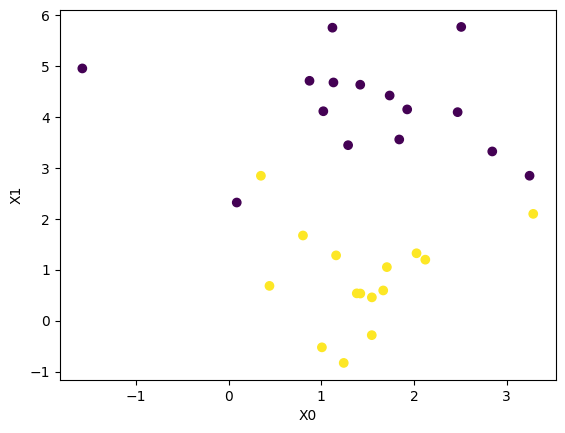

In [126]:
plt.scatter(X[:,0],X[:,1],c=y)
plt.xlabel('X0')
plt.ylabel('X1');

In [127]:
X

array([[ 0.34899733,  2.84843906],
       [ 1.42013331,  4.63746165],
       [ 0.44136967,  0.68492338],
       [ 1.70735537,  1.05401263],
       [ 1.28933778,  3.44969159],
       [ 1.1312175 ,  4.68194985],
       [ 2.50904929,  5.7731461 ],
       [ 1.54446238, -0.28296852],
       [ 1.15980096,  1.28456616],
       [ 2.47034915,  4.09862906],
       [ 0.80247216,  1.67515402],
       [ 2.84382807,  3.32650945],
       [ 2.02708529,  1.32599553],
       [ 0.87305123,  4.71438583],
       [ 3.2855582 ,  2.10004351],
       [-1.57671974,  4.95740592],
       [ 1.0220286 ,  4.11660348],
       [ 3.2460247 ,  2.84942165],
       [ 1.7373078 ,  4.42546234],
       [ 1.9263585 ,  4.15243012],
       [ 1.84070628,  3.56162231],
       [ 2.12178474,  1.20013556],
       [ 1.24212124, -0.82861894],
       [ 1.6679407 ,  0.59536091],
       [ 1.54561534,  0.45958936],
       [ 1.38280707,  0.5381105 ],
       [ 0.08848433,  2.32299086],
       [ 1.00671456, -0.52235428],
       [ 1.12031365,

<div class="alert alert-success">
<h2>Exercise</h2>

✏️ How would you divide the space using horizontal and vertical lines - play with different splits.
</div>

## Gini index

For classification, the *Gini index* is used as a cost function. A Gini score gives an idea of how successful a given split is - it means how classes are mixed between the two groups created by the split. A perfect separation results in a Gini score of 0, whereas the worst-case split of 50/50 classes results in a Gini score of 0.5 (for a binary class problem).

$$
G_m = \sum_{k=1}^K p_{m_k}(1 – p_{m_k}) = 1 - \sum_{k=1}^K p_{m_k}^2,
$$

where $K$ is the number of classes, and $p_{m_k}$ represents the proportion of training observations in the $m$th region (groups) that are from the $k$th class.

And then, weighted average over regions (groups)
$$
G = \sum_{m=1}^M \frac{N_m}{N} G_m
$$

where $N_m$ is a number of points in region (group) $m$, and $N$ is a total number of points.

In [128]:
def gini_index(groups, targets, classes):
    # count all samples at split point
    n_instances = float(sum([len(group) for group in groups]))
    # sum weighted Gini index for each group
    gini = 0.0
    for m in range(len(groups)): # index m
        group_size = len(groups[m])
        # avoid divide by zero
        if group_size == 0:
            continue
        score = 0.0
        for k in classes:
            y = targets[m]
            pmk = len(y[y==k])/group_size
            score += pmk * pmk
        # weight the group score by its relative size
        gini += (1.0 - score)*(group_size/n_instances)
    return gini

In [129]:
split_value =  5
feature_id = 1
index = X[:,feature_id] <= split_value
groups = [X[index], X[~index]]
target = [y[index], y[~index]]

In [130]:
index

array([ True,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False,  True])

In [131]:
groups

[array([[ 0.34899733,  2.84843906],
        [ 1.42013331,  4.63746165],
        [ 0.44136967,  0.68492338],
        [ 1.70735537,  1.05401263],
        [ 1.28933778,  3.44969159],
        [ 1.1312175 ,  4.68194985],
        [ 1.54446238, -0.28296852],
        [ 1.15980096,  1.28456616],
        [ 2.47034915,  4.09862906],
        [ 0.80247216,  1.67515402],
        [ 2.84382807,  3.32650945],
        [ 2.02708529,  1.32599553],
        [ 0.87305123,  4.71438583],
        [ 3.2855582 ,  2.10004351],
        [-1.57671974,  4.95740592],
        [ 1.0220286 ,  4.11660348],
        [ 3.2460247 ,  2.84942165],
        [ 1.7373078 ,  4.42546234],
        [ 1.9263585 ,  4.15243012],
        [ 1.84070628,  3.56162231],
        [ 2.12178474,  1.20013556],
        [ 1.24212124, -0.82861894],
        [ 1.6679407 ,  0.59536091],
        [ 1.54561534,  0.45958936],
        [ 1.38280707,  0.5381105 ],
        [ 0.08848433,  2.32299086],
        [ 1.00671456, -0.52235428],
        [ 1.42094543,  0.534

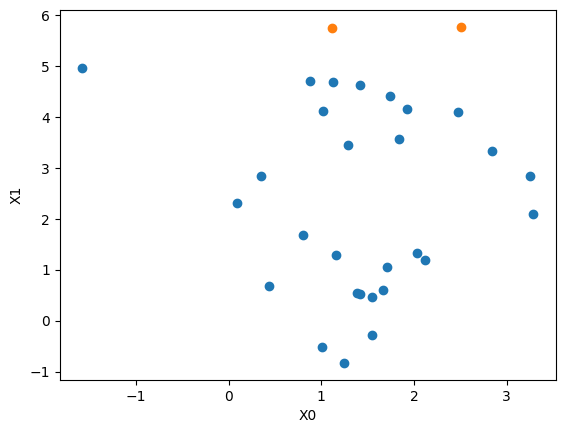

In [132]:
plt.scatter(groups[0][:,0],groups[0][:,1])
plt.scatter(groups[1][:,0],groups[1][:,1])
plt.xlabel('X0')
plt.ylabel('X1');

In [133]:
target

[array([1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
        1, 1, 1, 0, 1, 1]),
 array([0, 0])]

In [134]:
gini_index(groups,target,[1,0])

0.4642857142857143

<div class="alert alert-success">
<h2>Exercise</h2>

✏️ Try to compute the *gini index* using different split values and features to split.
</div>

## Selecting split

To determine the best split, first we define a function to return the groups based on a feature and value.

In [135]:
def create_split(feature_id, split_value, X, y):
    index = X[:,feature_id] < split_value
    groups = [X[index], X[~index]]
    targets = [y[index], y[~index]]
    return groups,targets

With the `gini_index` function above, and the `create_split` function, we can start evaluating the splits.

Given a dataset, (`X`), we check every value on each feature as a candidate split, evaluating the cost of the split using the gini index to find the best possible split.

The best split will be used as a node in our decision tree. The process is repeated for each subgroup (left and right) generated until a stopping criteria is reached. 

In [136]:
# Select the best split point for a dataset
def get_split_gini(X,y):
    class_values = set(y)
    best_score = 1
    b_feature_id, b_value = -1, 999
    
    for f_id in range(len(X[0])):
        for row in X:
            groups,targets = create_split(f_id, row[f_id], X, y)
            gini = gini_index(groups, targets, class_values)
            if gini < best_score:
                best_score = gini
                b_feature_id = f_id
                b_value = row[f_id]
                print(best_score)
    groups,targets = create_split(b_feature_id, b_value, X, y)
    return {'feature_id':b_feature_id, 'value':b_value, 'groups':groups, 'targets':targets}

In [137]:
node = get_split_gini(X,y)

0.4642857142857143
0.4639999999999999
0.45999999999999996
0.12444444444444436
0.11764705882352945
0.0625


In [138]:
node['value']

np.float64(2.8494216528496255)

In [139]:
node['feature_id']

1

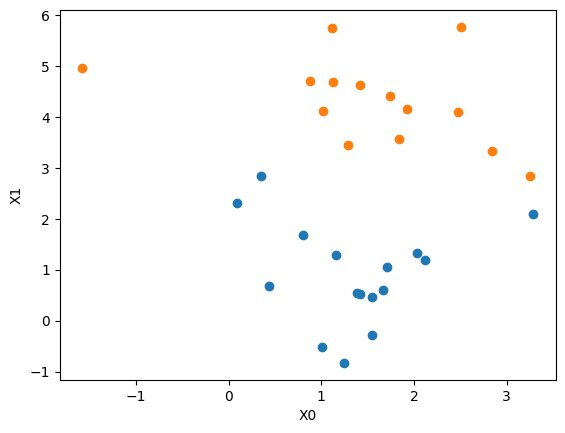

In [140]:
Xleft = node['groups'][0]
Xright = node['groups'][1]
plt.scatter(Xleft[:,0],Xleft[:,1])
plt.scatter(Xright[:,0],Xright[:,1])
plt.xlabel('X0')
plt.ylabel('X1');

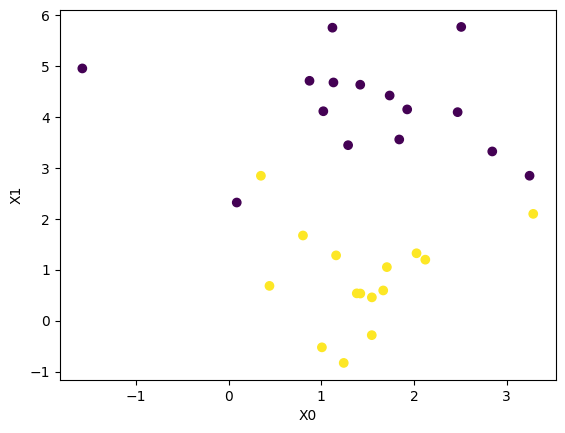

In [141]:
plt.scatter(X[:,0],X[:,1],c=y)
plt.xlabel('X0')
plt.ylabel('X1');

## Building the tree

To create a decision tree, first we create the root node using a `get_split` function over the whole dataset. To add the internal nodes we must determine whether the current node is a *terminal* node or an internal node. If it is internal, we continue splitting until the stop criteria is reached.

### Terminal Nodes

To determine if a node is a terminal, we can check two conditions:
  1. The maximum tree depth is reached;
  2. The number of training points in the node is less or equal than a given threshold.

Deeper trees represent a more complex model and are more likely to overfit the training data. Nodes with too few training points are considered too specific and more likely to overfit the training data.
  
These two stop conditions will be user-specified parameters (hyperparameters) to our model.

There is one more condition. If all rows belong to one group, then we will be unable to continue splitting and adding new child nodes.

To determine the final prediction, we select as prediction class the most common class value in the group.

In [142]:
def terminal_class(y):
    Yp = [v for v in y]
    return max(set(Yp), key=Yp.count)

In [143]:
terminal_class(np.array([0,0,1,0,1,0,1,1,1]))

np.int64(1)

### Internal Nodes

The internal nodes are created by calling a `get_split` function over the created groups. New nodes added to an existing node are *child nodes*, and the parent node is an *internal node*. A node can have zero children (a terminal node), one child (one side makes a prediction) or two child nodes (left and right nodes).

Nodes store information about which feature is used for the decision, its value (feature < value), the samples associated to the node, and reference to the left and right nodes.

In [144]:
root = {'feature_id':None, 'value':None, 'samples':[X,y],'class':None,'left':None,'right':None}

The `split` function is the recursive function used to determine whether the node is a terminal node. In case of an internal node, it split the samples associated with the node and calls itself with the left and right generated groups of samples. 

In [145]:
# Create child splits for a node or make terminal
def split(node, current_depth, max_depth, min_size):
    X,y = node['samples']

    # check for max depth
    if current_depth >= max_depth:
        node['class'] = terminal_class(y)
        node['left'] = node['right'] = None
        return
    # check for min number of samples
    if len(X) <= min_size: 
        node['class'] = terminal_class(y)
        node['left'] = node['right'] = None
        return

    res = get_split_gini(X,y)
    samples_left = res['groups'][0],res['targets'][0]
    samples_right = res['groups'][1],res['targets'][1]
    
    # check if no split benefit
    if len(X)==len(samples_left[0]) or len(X)==len(samples_right[0]):
        node['class'] = terminal_class(y)
        node['left'] = node['right'] = None
        return
        
    node['feature_id'] = res['feature_id']
    node['value'] = res['value']
    
    # process left child
    if len(samples_left[0])>0:
        node['left'] = {'feature_id':None, 'value':None, 'samples':samples_left,
                        'class':None,'left':None,'right':None}
        split(node['left'], current_depth+1, max_depth, min_size)

    # process right child
    if len(samples_right[0])>0:
        node['right'] = {'feature_id':None, 'value':None, 'samples':samples_right,
                         'class':None,'left':None,'right':None}
        split(node['right'], current_depth+1, max_depth, min_size)

Finally, our function to build the decision tree `build_tree`, takes as input the features and target values, the maximum allowed depth and the minimum size of samples in a node.

In [146]:
def build_tree(X,y, max_depth, min_size):
    root = {'feature_id':None, 'value':None, 'samples':[X,y],'class':None,'left':None,'right':None}
    split(root, 1, max_depth, min_size)
    return root

In [147]:
y

array([1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 0, 1])

In [148]:
dt = build_tree(X, y, 3, 1)

0.4642857142857143
0.4639999999999999
0.45999999999999996
0.12444444444444436
0.11764705882352945
0.0625
0.0
0.0


In [149]:
def print_tree(node, columns, depth=1):
    print(' '*(depth-1)*4, end='')
    if node['feature_id']!=None:
        feature_name = columns[node['feature_id']]
        print("[({} < {}) samples:{} class:{}]".format(feature_name, node['value'],
                                                       len(node['samples'][0]), node['class']))
    else:
        print("[samples:{} class:{}]".format(len(node['samples'][0]), node['class']))

    if node['left']:
        print_tree(node['left'], columns, depth+1)
    if node['right']:
        print_tree(node['right'], columns, depth+1)

In [150]:
print_tree(dt, ['X0','X1'])

[(X1 < 2.8494216528496255) samples:30 class:None]
    [(X0 < 0.3489973308078649) samples:16 class:None]
        [samples:1 class:0]
        [samples:15 class:1]
    [(X0 < 1.4201333112919208) samples:14 class:None]
        [samples:6 class:0]
        [samples:8 class:0]


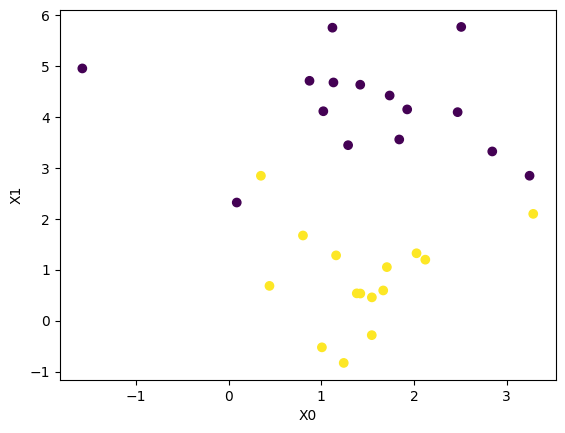

In [151]:
plt.scatter(X[:,0],X[:,1],c=y)
plt.xlabel('X0')
plt.ylabel('X1');

## Prediction

To make predictions with a decision tree, we traverse the tree with the given data. Starting from the root, we evaluate the condition on the node taking the branch that evaluates as true until we reach a terminal node.

In [152]:
def predict(node, row):
    feature_id = node['feature_id']
    # test for teminal node
    if feature_id == None:
        return node['class']
    else:
        if row[feature_id] < node['value']:
            return predict(node['left'], row)
        else:
            return predict(node['right'], row)

In [153]:
def predictions(node, data):
    return np.apply_along_axis(lambda row: predict(node,row), 1, data)

In [154]:
Yp = predictions(dt,X)

In [155]:
dt

{'feature_id': 1,
 'value': np.float64(2.8494216528496255),
 'samples': [array([[ 0.34899733,  2.84843906],
         [ 1.42013331,  4.63746165],
         [ 0.44136967,  0.68492338],
         [ 1.70735537,  1.05401263],
         [ 1.28933778,  3.44969159],
         [ 1.1312175 ,  4.68194985],
         [ 2.50904929,  5.7731461 ],
         [ 1.54446238, -0.28296852],
         [ 1.15980096,  1.28456616],
         [ 2.47034915,  4.09862906],
         [ 0.80247216,  1.67515402],
         [ 2.84382807,  3.32650945],
         [ 2.02708529,  1.32599553],
         [ 0.87305123,  4.71438583],
         [ 3.2855582 ,  2.10004351],
         [-1.57671974,  4.95740592],
         [ 1.0220286 ,  4.11660348],
         [ 3.2460247 ,  2.84942165],
         [ 1.7373078 ,  4.42546234],
         [ 1.9263585 ,  4.15243012],
         [ 1.84070628,  3.56162231],
         [ 2.12178474,  1.20013556],
         [ 1.24212124, -0.82861894],
         [ 1.6679407 ,  0.59536091],
         [ 1.54561534,  0.45958936],
    

In [156]:
from sklearn.metrics import accuracy_score
print("Model accuracy:",accuracy_score(y,Yp))

Model accuracy: 1.0


In [157]:
def plot_decision(X, Y, tree, title):
    plot_step = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = predictions(tree, np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=plt.cm.Paired)  
    plt.scatter(X[:,0],X[:,1],c=Y)
    plt.title(title);

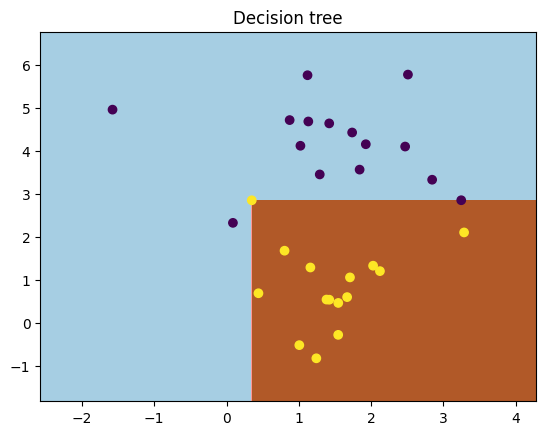

In [158]:
plot_decision(X,y,dt,"Decision tree")

<div class="alert alert-success">
<h2>Exercise</h2>

✏️ Generate a decision tree to model the following generated data:
    
    X, y = make_blobs(n_samples=50, centers=2, n_features=2, random_state=5)

Verify the accuracy of the model by splitting the data into training (%60 of input data) and testing data (%40). 
</div>

In [159]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=50, centers=2, n_features=2, random_state=5)

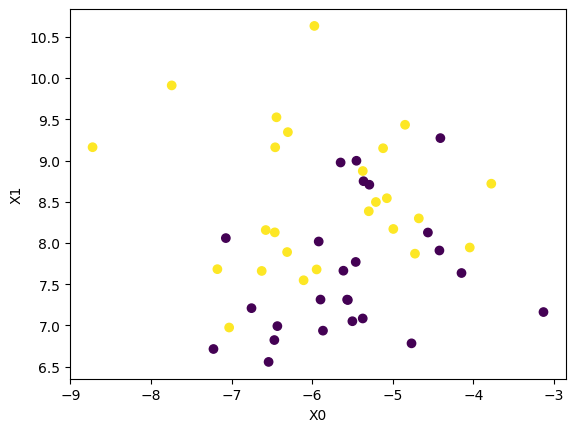

In [160]:
plt.scatter(X[:,0],X[:,1],c=y)
plt.xlabel('X0')
plt.ylabel('X1');

In [161]:
dt = build_tree(X, y, 6, 1)

0.48717948717948717
0.47771836007130125
0.46875
0.4597701149425287
0.4466666666666667
0.39215686274509803
0.3831168831168832
0.3571428571428571
0.12698412698412698
0.11428571428571423
0.07142857142857142
0.0
0.0
0.0
0.0
0.0
0.0
0.41041666666666665
0.3927272727272727
0.3819444444444446
0.3571428571428572
0.13265306122448983
0.119047619047619
0.10714285714285714
0.375
0.25
0.0
0.0
0.0
0.0
0.0
0.4499999999999999
0.43333333333333335
0.4210526315789474
0.4166666666666667
0.38888888888888884
0.35294117647058815
0.0
0.0
0.0
0.4549019607843137
0.38991596638655457
0.34937611408199637
0.21818181818181817
0.18181818181818182
0.2222222222222222
0.0


In [162]:
Yp = predictions(dt,X)

In [163]:
from sklearn.metrics import accuracy_score
print("Model accuracy:",accuracy_score(y,Yp))

Model accuracy: 0.96


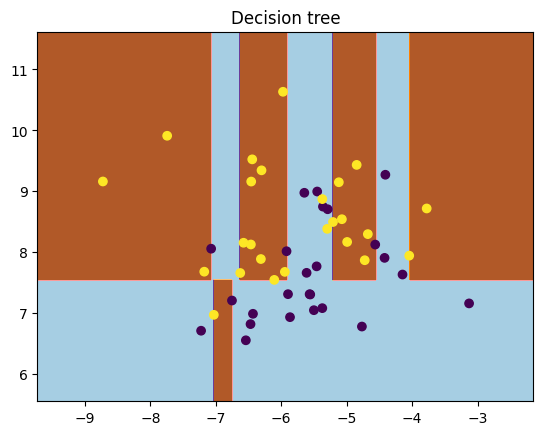

In [164]:
plot_decision(X,y,dt,"Decision tree")

Let's try more realistic data. In this case, we will use the [breast cancer dataset](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Diagnostic%29). Scikit-learn provides functions to load a common dataset for learning and experimenting with new algorithms.

In [165]:
from sklearn.datasets import load_breast_cancer, load_wine
data = load_breast_cancer()
# data = load_wine()
features = pd.DataFrame(data.data,columns=data.feature_names)
target = data.target

The breast cancer dataset has data classified in two classes *malignant* and *benign*, and 30 features and 569 samples:

In [166]:
data.target_names

array(['malignant', 'benign'], dtype='<U9')

In [167]:
features.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [168]:
features.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [169]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split( data.data , target , test_size = 0.2, random_state = 5)

A decision tree is built to classify the data with a maximum of 15 depth levels and a minimum of 10 samples per terminal node.

In [170]:
dt = build_tree(X_train, Y_train, 15, 10)

0.2873862401759397
0.25585692105421937
0.2548428576163914
0.2216228953770482
0.21852601798063434
0.21581088592659278
0.2100837828837829
0.20873740863598872
0.2084837188198885
0.2048877568982178
0.19752630744997163
0.19714538759836683
0.1943848947662508
0.17111324050099563
0.16380243412501488
0.157127776488447
0.15670073769021955
0.15585310746601072
0.1538682386717969
0.15265306122448988
0.14935722697270282
0.1488216911293835
0.14768084598686437
0.14568858463940432
0.12575058237958125
0.12466991361807224
0.12386844978588635
0.11776909579160641
0.11658257229580946
0.1161232476706286
0.11111232868706354
0.10952981444784717
0.10521138912855907
0.10206376448904717
0.09488992974238877
0.09422659003269426
0.09140478756594246
0.08398848778486398
0.0796824127491861
0.06268394167991607
0.061704009058869996
0.06147386620598209
0.061102455650518826
0.06083547522694954
0.06020679913362836
0.059951444705113
0.05968143354902933
0.05961032706196709
0.05909211459432312
0.058769727403156266
0.0583566309

In [171]:
print_tree(dt, data.feature_names)

[(worst concave points < 0.1424) samples:455 class:None]
    [(worst area < 967.0) samples:305 class:None]
        [(worst perimeter < 102.2) samples:287 class:None]
            [(mean radius < 14.99) samples:249 class:None]
                [(worst texture < 33.37) samples:248 class:None]
                    [(mean radius < 13.2) samples:235 class:None]
                        [(mean radius < 10.51) samples:194 class:None]
                            [(mean radius < 9.606) samples:51 class:None]
                                [(mean radius < 8.888) samples:21 class:None]
                                    [(mean radius < 8.571) samples:13 class:None]
                                        [samples:5 class:1]
                                        [samples:8 class:1]
                                    [samples:8 class:1]
                                [samples:30 class:1]
                            [samples:143 class:1]
                        [samples:41 class:1]
               

In [172]:
Yp_train = predictions(dt,X_train)

In [173]:
print("Model accuracy (train):",accuracy_score(Y_train,Yp_train))

Model accuracy (train): 0.9868131868131869


In [174]:
Yp_test = predictions(dt,X_test)

In [175]:
print("Model accuracy (test):",accuracy_score(Y_test,Yp_test))

Model accuracy (test): 0.9473684210526315


In [176]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_train, Yp_train)
pd.DataFrame(cm)

,0,1
0,163,1
1,5,286


In [177]:
import seaborn as sns; #sns.set()

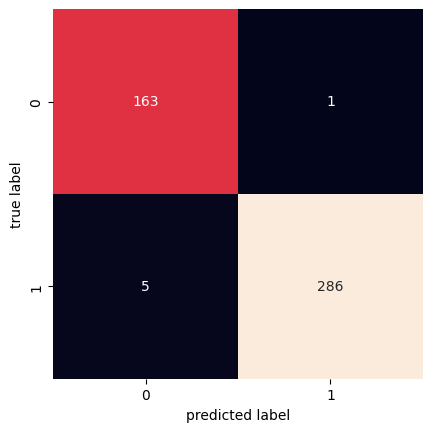

In [178]:
sns.heatmap(cm, square=True, annot=True, fmt='d', cbar=False)
plt.ylabel('true label')
plt.xlabel('predicted label');

In [179]:
cm = confusion_matrix(Y_test, Yp_test)

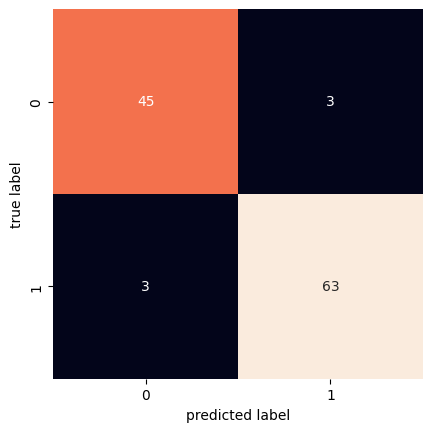

In [180]:
sns.heatmap(cm, square=True, annot=True, fmt='d', cbar=False)
plt.ylabel('true label')
plt.xlabel('predicted label');

## Cross-entropy

In this context, *entropy* characterizes the (im)purity of a collection of samples. If all samples are in only one class, the entropy will be zero (there is no impurities). If half of the samples are of the positive class and half are of the negative class, then entropy is one. The entropy is defined as:

$$
H(S) = \sum_{k=1}^K -p_{k}\log(p_{k}),
$$

where $K$ is the number of classes, and $p_{k}$ represents the proportion of training observations in $S$ that are from the $k$-th class.

In [181]:
def entropy(s, classes):
    m = len(s)
    if m==0:
        return 0
    pmk = [len(s[s==k])/m for k in classes]
    d = 0.0
    for p in pmk:
        if p!=0.0:
            d -= p*np.log2(p)
    return d

In [182]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=30, centers=2, n_features=2, random_state=0)

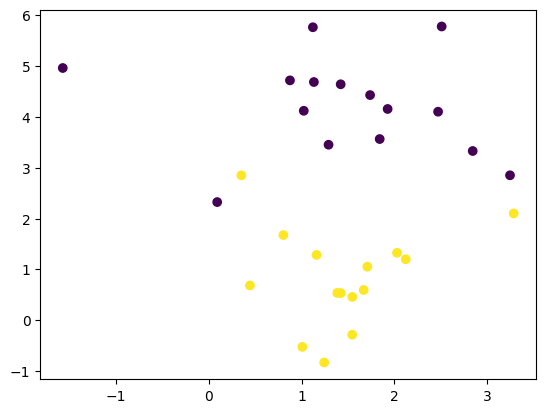

In [183]:
plt.scatter(X[:,0],X[:,1],c=y);

In [184]:
split_value =  4.0
feature_id = 1
index = X[:,feature_id] <= split_value
groups = [X[index], X[~index]]
target = [y[index], y[~index]]

In [185]:
target

[array([1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])]

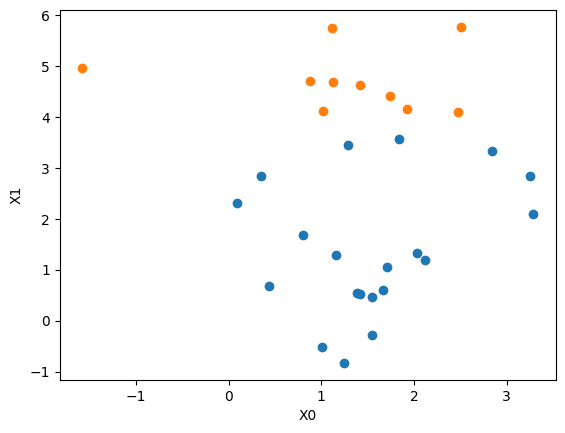

In [186]:
plt.scatter(groups[0][:,0],groups[0][:,1])
plt.scatter(groups[1][:,0],groups[1][:,1])
plt.xlabel('X0')
plt.ylabel('X1');

In [187]:
entropy(target[0],[0,1]),entropy(target[1],[0,1])

(np.float64(0.8112781244591328), np.float64(0.0))

<div class="alert alert-success">
<h2>Exercise</h2>

✏️ Play with different splits and observe values of entropy. Explain their values.
</div>

### Information Gain

Information gain is the measure of difference in entropy between entropy of the dataset before the split, ($S$), and after the dataset is split into groups, ($T$), based on a feature.  

$$
Gain(S) = H(S) - \sum_{t\in T}  p(t) . H(t)
$$

where $p(t)$ is a size of a group $t$ divided by a number of points in the dataset. Under this measurement, constructing a decision tree implies finding a feature that returns the highest information gain (i.e., the most pure branches). It means the highest lost of entropy.

In [188]:
# Select the best split point for a dataset
def get_split_entropy(X,y):
    class_values = set(y)
    entropy_y = entropy(y, class_values)
    
    best_score = 0
    b_feature_id, b_value = -1, 999
    
    for f_id in range(len(X[0])):
        for row in X:
            groups,targets = create_split(f_id, row[f_id], X, y)
            score = 0.0
            # Calculating the information gain
            for target in targets:
                score += len(target)/len(y) * entropy(target, class_values)
            info_gain = entropy_y - score
            if info_gain > best_score:
                best_score = info_gain
                b_feature_id = f_id
                b_value = row[f_id]
    groups,targets = create_split(b_feature_id, b_value, X, y)
    return {'feature_id':b_feature_id, 'value':b_value, 'groups':groups, 'targets':targets}

Let's change our `split` and `build_tree` functions slightly to receive a $splitter$ function (`get_split_gini` or `get_split_entropy`).

In [189]:
# Create child splits for a node or make terminal
def split(node, current_depth, max_depth, min_size, splitter):
    X,y = node['samples']

    # check for max depth
    if current_depth >= max_depth:
        node['class'] = terminal_class(y)
        node['left'] = node['right'] = None
        return
    # check for min number of samples
    if len(X) <= min_size: 
        node['class'] = terminal_class(y)
        node['left'] = node['right'] = None
        return

    # Use the provided split function (gini index or entropy based)
    res = splitter(X,y)
    
    samples_left = res['groups'][0],res['targets'][0]
    samples_right = res['groups'][1],res['targets'][1]
    
    # check if no split benefit
    if len(X)==len(samples_left[0]) or len(X)==len(samples_right[0]):
        node['class'] = terminal_class(y)
        node['left'] = node['right'] = None
        return
        
    node['feature_id'] = res['feature_id']
    node['value'] = res['value']
    
    # process left child
    if len(samples_left[0])>0:
        node['left'] = {'feature_id':None, 'value':None, 'samples':samples_left,
                        'class':None,'left':None,'right':None}
        split(node['left'], current_depth+1, max_depth, min_size, splitter)

    # process right child
    if len(samples_right[0])>0:
        node['right'] = {'feature_id':None, 'value':None, 'samples':samples_right,
                         'class':None,'left':None,'right':None}
        split(node['right'], current_depth+1, max_depth, min_size, splitter)

In [190]:
def build_tree(X,y, max_depth, min_size, splitter):
    root = {'feature_id':None, 'value':None, 'samples':[X,y],'class':None,'left':None,'right':None}
    split(root, 1, max_depth, min_size, splitter)
    return root

In [191]:
dt_e = build_tree(X, y, 30, 3, get_split_entropy)

In [192]:
print_tree(dt_e, ['X0','X1'])

[(X1 < 2.8494216528496255) samples:30 class:None]
    [(X0 < 0.3489973308078649) samples:16 class:None]
        [samples:1 class:0]
        [samples:15 class:1]
    [samples:14 class:0]


In [193]:
Yp = predictions(dt_e,X)

In [194]:
print("Model accuracy:",accuracy_score(y,Yp))

Model accuracy: 1.0


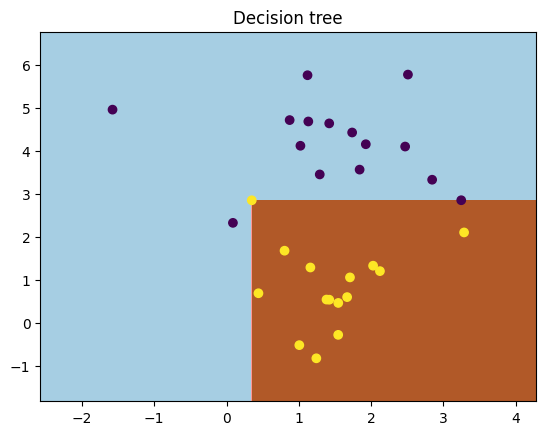

In [195]:
plot_decision(X,y,dt_e,"Decision tree")

Calculating again the decision tree using the gini index, we obtain the following.

In [196]:
dt_g = build_tree(X, y, 30, 3, get_split_gini)

0.4642857142857143
0.4639999999999999
0.45999999999999996
0.12444444444444436
0.11764705882352945
0.0625
0.0
0.0
0.0
0.0
0.0
0.0
0.0


In [197]:
print_tree(dt_g, ['X0','X1'])

[(X1 < 2.8494216528496255) samples:30 class:None]
    [(X0 < 0.3489973308078649) samples:16 class:None]
        [samples:1 class:0]
        [samples:15 class:1]
    [(X0 < 1.4201333112919208) samples:14 class:None]
        [(X0 < 1.2893377801973964) samples:6 class:None]
            [(X0 < 1.1312175042434114) samples:5 class:None]
                [(X0 < 0.8730512267529372) samples:4 class:None]
                    [samples:1 class:0]
                    [samples:3 class:0]
                [samples:1 class:0]
            [samples:1 class:0]
        [samples:8 class:0]


In [198]:
Yp = predictions(dt_g,X)
print("Model accuracy:",accuracy_score(y,Yp))

Model accuracy: 1.0


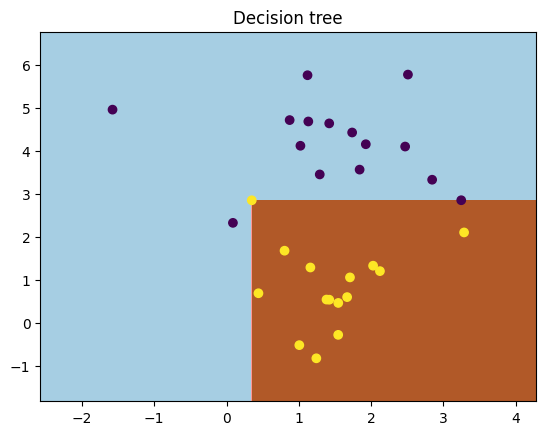

In [199]:
plot_decision(X,y,dt_g,"Decision tree")

<div class="alert alert-success">
<h2>Exercise</h2>

✏️ Generate a decision tree for the breast cancer dataset using entropy. Verify the accuracy of your model by splitting the data into training (%60 of input data) and testing data (%40). Compare the results with the ones obtained using the gini index.
</div>

## Decision tree using Scikit-learn

Scikit learn provides the module `tree` to create decision tree models, with two variations: classification (`DecisionTreeClassifier`); and regression (`DecisionTreeRegressor`). 

In [200]:
from sklearn import tree

In [201]:
model = tree.DecisionTreeClassifier()
model

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

By default, the quality of the split is gini index. To change it to use entropy, we need to specify `criterion='entropy'` to the classifier constructor. Similarly, we can specify the maximum depth (`max_depth`) and minimum samples per leaf (`min_samples_leaf`).

As usual, using Scikit learn, we use the `fit` method to train the model.

In [202]:
X, y = make_blobs(n_samples=50, centers=2, n_features=2, random_state=5)

In [203]:
model.fit(X,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

There is not a direct way to plot the decision tree generated using scikit learn. However, we can export the tree on a *graphviz* format to render it.

First we need to install support for graphviz (in case we dont have it yet):

In [204]:
# conda install python-graphviz

In [205]:
# conda install -c conda-forge pygraphviz

In [206]:
# pip install graphviz

In [207]:
import graphviz

In [208]:
dot_data = tree.export_graphviz(model, out_file=None, 
                      feature_names=['X0','X1'],  
                      class_names=['0','1'],  
                      filled=True, rounded=True,  
                      special_characters=True,
                            label='root',
                               leaves_parallel=False)  
graph = graphviz.Source(dot_data)  
graph.render('tree',format = 'png');

![](tree.png)

In [209]:
Yp = model.predict(X)

In [210]:
print("Model accuracy (gini index):",accuracy_score(y,Yp))

Model accuracy (gini index): 1.0


In [211]:
def plot_decision_sl(X, Y, tree, title):
    plot_step = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = tree.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=plt.cm.Paired)  
    plt.scatter(X[:,0],X[:,1],c=Y)
    plt.title(title);

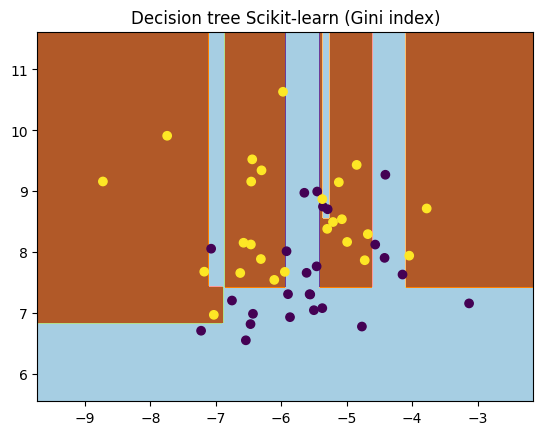

In [212]:
plot_decision_sl(X, y, model, "Decision tree Scikit-learn (Gini index)")

<div class="alert alert-success">
<h2>Exercise</h2>

✏️ Using the *entropy* criteria, instead of the gini index, generate a decision tree for the following dataset:
    
    X, y = make_blobs(n_samples=50, centers=2, n_features=2, random_state=5)
    
Plot the generated tree using graphviz and plot the decision boundaries.
</div>

# Regression with decission trees

As we mentioned before, we can use decision trees to generate a model for a regression problem. Using the module `DecisionTreeRegressor` provided by Scikit learn, we get the following.

In [213]:
model_reg = tree.DecisionTreeRegressor(max_depth=200)
model_reg

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",200
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_

In [214]:
X = np.sort(5 * np.random.rand(40, 1), axis=0)
y = np.cos(X+1.5).ravel()+np.random.ranf(40)/4

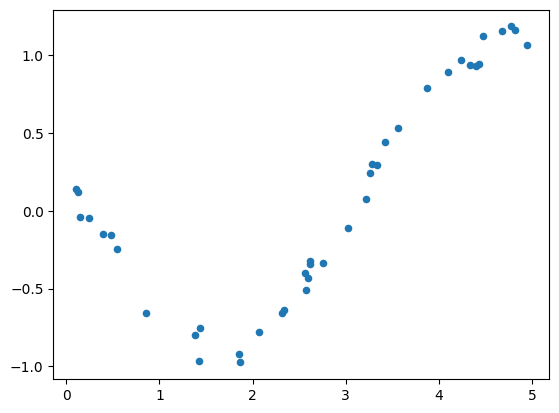

In [215]:
plt.scatter(X, y, s=20);

In [216]:
model_reg.fit(X,y)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",200
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_

In [217]:
X_test = np.arange(min(X).item(), max(X).item(), 0.01)[:, np.newaxis]
Yp = model_reg.predict(X_test)

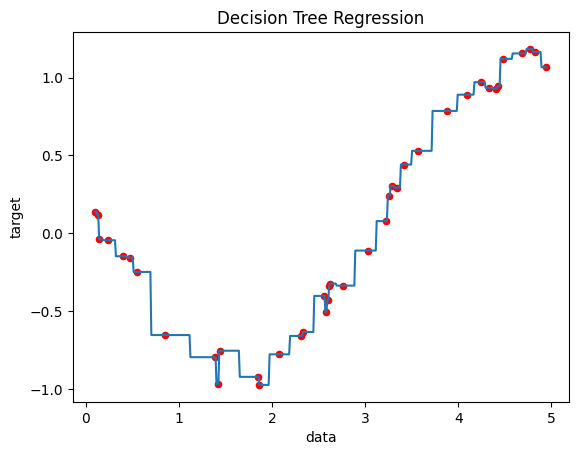

In [218]:
plt.scatter(X, y, s=20, c="red")
plt.xlabel("data")
plt.ylabel("target")
plt.title("Decision Tree Regression")
plt.plot(X_test,Yp);

<div class="alert alert-success">
<h2>Exercise</h2>

✏️ Generate a regression model using a decision tree, but this time limit the maximum depth allowed to 2 and 5. Plot the resulting predictions for each new model and compare the results.
</div>

# Ensembles

As we observed from the results, decision trees usually produce overfitting models. The deeper the tree, the more overfitting the model has. To deal with this problem, we can prune the tree. For example, by removing terminal nodes and evaluating the effect of removing the leaf over the cost function. We remove a leaf only if the evaluation produces a drop in the cost function over the whole test dataset.

Another approach is work with ensembles. An ensemble method uses multiple learning algorithms (models) to obtain better predictive performance. In general, the performance obtained using ensembles exceed the one obtained from any of the learning algorithms used in the ensemble.

Some of the techniques that use ensembles are *random forest*, *bagging* and *boosting*. 

Let's generate the following dataset.

In [219]:
X, y = make_blobs(n_samples=150, centers=4, n_features=2, cluster_std=1.2, random_state=0)

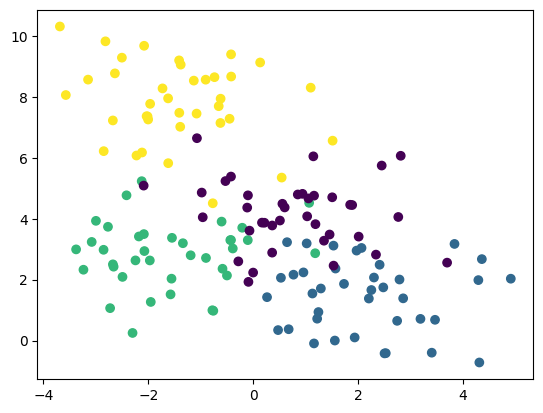

In [220]:
plt.scatter(X[:,0],X[:,1], c=y);

## Random forest

Random forest is an ensemble method where each model in the ensemble is a decision tree generated by randomly selecting the feature to split on each node. The feature to split is selected from a random sample of $k$ features from all the features (predictors). The split is allowed to use only one of the $k$ features ($k=\sqrt{m}$, where $m$ is the total number of features). The final prediction is made after calculating the prediction on each model in the ensemble and selecting the class prediction with more occurrences. 

First, we create a set of decision trees using `ExtraTreeClassifier`, a module from scikit learn, to generate random decision trees.

In [221]:
def build_forest(X, y, n_trees, max_depth=None):
    forest = []
    for i in range(n_trees):
        model = tree.ExtraTreeClassifier(max_depth=max_depth)
        model.fit(X,y)
        forest.append(model)
    return forest

In this case, the prediction function evaluates each model in the forest to obtain its predictions and later obtain the prediction with the most occurrences.

In [222]:
def rf_predict(forest, X):
    Yps = []
    for m in forest:
        Yps.append(m.predict(X))
    Yps = np.array(Yps).T
    Yp = []
    for i in range(len(X)):
        val, counts = np.unique(Yps[i], return_counts=True)
        j = np.argmax(counts)
        Yp.append(val[j])
    return np.array(Yp).reshape(len(X),1)

In [223]:
forest = build_forest(X, y, 50, 12)
Yp = rf_predict(forest, X)

In [224]:
print("Model accuracy (random forest):",accuracy_score(y,Yp))

Model accuracy (random forest): 1.0


In [225]:
def plot_decision_rf(X, Y, forest, title):
    plot_step = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = rf_predict(forest, np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=plt.cm.Paired)  
    plt.scatter(X[:,0],X[:,1],c=Y)
    plt.title(title);

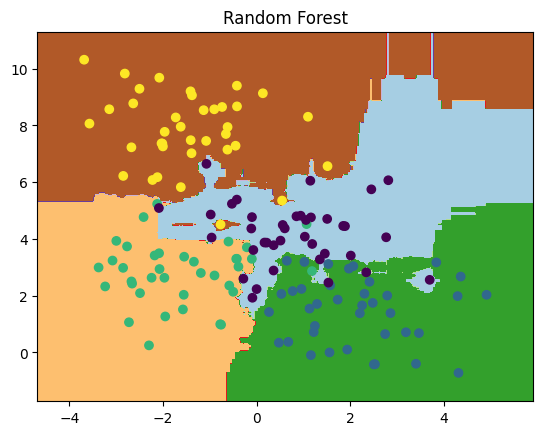

In [104]:
plot_decision_rf(X, y, forest, "Random Forest")

If we use only one of the models in the forest, we can observe that its performance is not as good as the whole set of models.

In [226]:
dt = forest[34]
dt.fit(X, y)
Yp = dt.predict(X)

In [227]:
print("Model accuracy (random forest):",accuracy_score(y,Yp))

Model accuracy (random forest): 0.9266666666666666


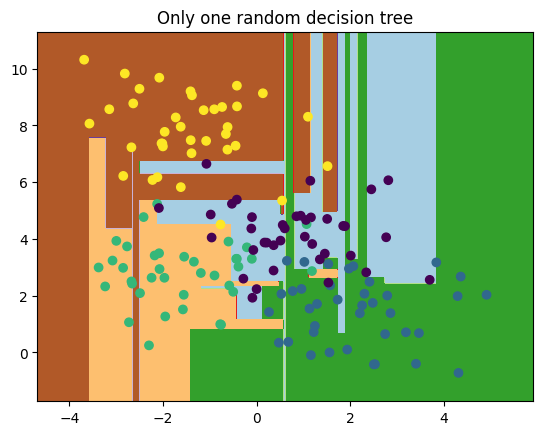

In [228]:
plot_decision_sl(X, y, dt, "Only one random decision tree")

Scikit learn provides the module `RandomForestClassifier` to generate a model using random forest.

In [229]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=50, random_state=0, max_depth=12)
model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

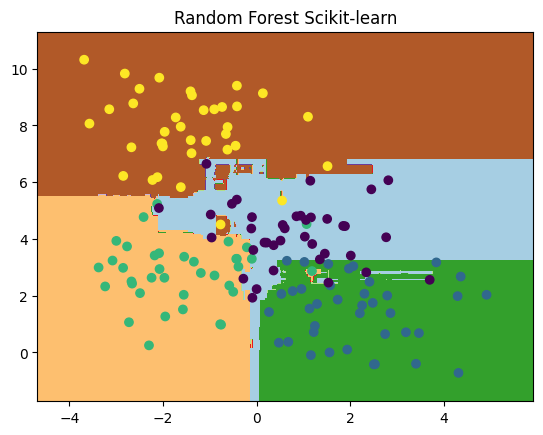

In [230]:
plot_decision_sl(X, y, model, "Random Forest Scikit-learn")

In [231]:
Yp = model.predict(X)

In [232]:
print("Model accuracy (random forest scikit-learn):",accuracy_score(y,Yp))

Model accuracy (random forest scikit-learn): 1.0


## Bagging

Bagging or *bootstrap aggregation* is another ensemble method. Bagging involves generating multiple models (decision trees in this case) from the same model specification but training them with different samples from a dataset (bootstrapped training sets). After each model is trained with the bootstrapped training sets, we get a prediction for each set, and we average the predictions in the case of regression or select the maximum occurrences in the case of classification.

Using the `BaggingClassifier` module from scikit learn, we have the following.

In [233]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

tree = DecisionTreeClassifier()
bag = BaggingClassifier(tree, n_estimators=50, max_samples=0.8, random_state=1) # 100

bag.fit(X, y)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeClassifier()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",50
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",0.8
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",1
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


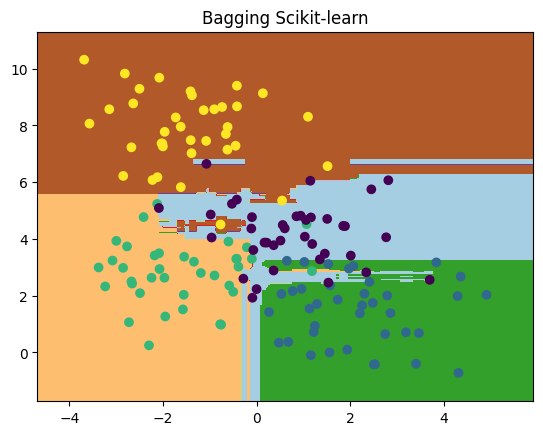

In [234]:
plot_decision_sl(X, y, bag, "Bagging Scikit-learn")

In [235]:
Yp = bag.predict(X)

In [236]:
print("Model accuracy (bagging scikit-learn):",accuracy_score(y,Yp))

Model accuracy (bagging scikit-learn): 0.9933333333333333


## Boosting

Boosting is a technique where weak models are combined to produce a strong model or a strong learner. Similar to the ensembles presented previously, boosting combines the result of the models to produce a model with better performance. This combination is performed by using average or weighted average, or considering predictions with higher occurrence.
In the case of decision trees, boosting works in a similar way to bagging, but the trees are grown sequentially; each tree uses information from the previously grown trees. Each new tree tries to focus on samples that have been misclassified rather than on the target variable. Hence, each tree is small and will slowly improve predictions in areas where it does not perform well.

Two examples of boosting algorithms are AdaBoost (Adaptive Boosting) and Gradient Tree Boosting.

Scikit learn provides modules for both of the algorithms, `AdaBoostClassifier` (and `AdaBoostRegressor` for regression), and `GradientBoostingClassier` (and `GradientBoostingRegressor`).

The following is an example using AdaBoosting algorithm. 

In [238]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

tree = DecisionTreeClassifier()
model = AdaBoostClassifier(n_estimators=50, estimator=tree, learning_rate=1)

Similar to our previous example, `n_estimators` defines the number of slow learners (models) to use. The parameter `learning_rate` is used to control the contribution of each slow learner to the final decision. We can specify any model as base estimator (that provides the scikit learn interface).

In [240]:
model.fit(X, y)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeClassifier()
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None


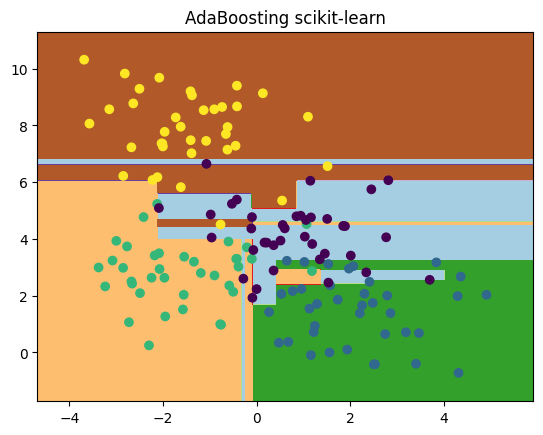

In [241]:
plot_decision_sl(X, y, model, "AdaBoosting scikit-learn")

In [242]:
Yp = model.predict(X)

In [243]:
print("Model accuracy (AdaBoosting scikit-learn):",accuracy_score(y,Yp))

Model accuracy (AdaBoosting scikit-learn): 1.0


Using Gradient Boosting over the dataset, we obtain the following.

In [244]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(n_estimators=50, learning_rate=1.0, max_depth=1)

In [245]:
model.fit(X, y)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",1.0
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",50
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",1
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, `

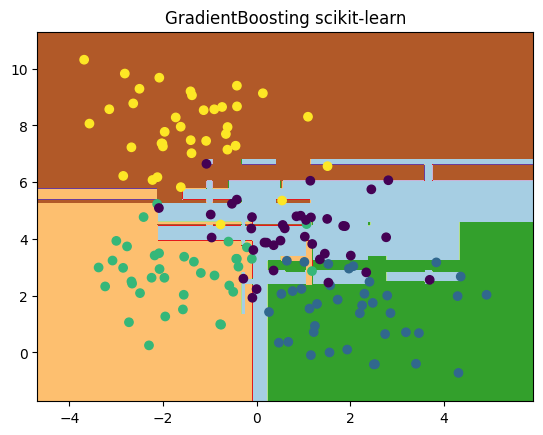

In [246]:
plot_decision_sl(X, y, model, "GradientBoosting scikit-learn")

In [ ]:
Yp = model.predict(X)

In [ ]:
print("Model accuracy (GradientBoosting scikit-learn):",accuracy_score(y,Yp))

Model accuracity (GradientBoosting scikit-learn): 1.0


<div class="alert alert-success">
<h2>Exercise</h2>

✏️ Using the breast cancer dataset, generate models for random forest, bagging and boosting and compare their performance using test and training datasets. Use cross-validation to compute the performance (`sklearn.model_selection.cross_val_score`).
</div>

## Bagging vs Boosting -- Bias and Variance of Models

### Bias and Variance

#### Bias

Refers to the <b>systematic errors</b> in a model's predictions due to oversimplified assumptions. \
High bias model -- model has not captured pattern(s) in data:

- Tends to underfit the data
- Makes consistent errors across different training sets
- Often occurs in simpler models, like linear algorithms

#### Variance

Refers to the model's sensitivity to fluctuations in the training data. \
High variance model - model has captured 'too much', for example, also pattern(s) for noisy data:

- Tends to overfit the data
- Produces different predictions for similar inputs across training sets
- Is more common in complex, non-linear models

### Comparison

<b>Objective:</b> Bagging primarily reduces variance, while boosting reduces both bias and variance.

<b>Training Process:</b> Bagging trains models in parallel, while boosting trains them sequentially.

<b>Error Handling:</b> Bagging gives equal weight to all instances, while boosting focuses more on misclassified instances.

<b>Overfitting:</b> Bagging is generally less prone to overfitting due to its averaging mechanism.

<b>Use Cases:</b> Bagging works well with high-variance, low-bias models (e.g., decision trees), while boosting is effective for both high-bias and high-variance scenarios.

# Recap

In this section we introduce Decision Trees as techniques for classification and regression. Decision trees are easy to interpret compared with other techniques, because they can be seen as a set of rules that guide the prediction. To build a decision tree we can use the Gini index and Entropy/Information Gain to determine when and where a new node in the tree is needed. We introduce ensembles, which consist of a collection of models that are evaluated. By combining their predictions, we produce a more robust model. We show Random Forest, Bagging and Boosting as examples of algorithms using ensembles.